# Proyecto de clasificación de imágenes

In [ ]:
import os
import random
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Conecta el entorno de ejecución de Colab con tu almacenamiento de Google Drive.

Esto permite acceder directamente a las imágenes guardadas en carpetas en Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Paso 1: Carga del conjunto de datos

Definición de rutas: Establece la ubicación de las imágenes originales y crea una nueva estructura de carpetas (train/cats, train/dogs, etc.).

Crea listas separadas para archivos de gatos y perros basándose en el nombre del archivo.

Función split_and_copy: * Mezcla las imágenes aleatoriamente.

Divide el set en 80% entrenamiento y 20% prueba.

Copia físicamente los archivos a sus nuevas carpetas correspondientes usando shutil.copy.

In [ ]:
# Carpeta donde están TODAS las imágenes mezcladas
data_dir = '/content/drive/MyDrive/4geeks/dogs-vs-cats/dogs-vs-cats/train'


# Crear estructura de carpetas final
train_cats = os.path.join(data_dir, "train", "cats")
train_dogs = os.path.join(data_dir, "train", "dogs")
test_cats  = os.path.join(data_dir, "test", "cats")
test_dogs  = os.path.join(data_dir, "test", "dogs")

for folder in [train_cats, train_dogs, test_cats, test_dogs]:
    os.makedirs(folder, exist_ok=True)

# Listar imágenes
all_images = [img for img in os.listdir(data_dir) if img.endswith(".jpg")]

# Separar por clase según el nombre del archivo
cat_images = [img for img in all_images if img.lower().startswith("cat")]
dog_images = [img for img in all_images if img.lower().startswith("dog")]

def split_and_copy(images, train_path, test_path, train_ratio=0.8):
    random.shuffle(images)
    split_idx = int(len(images) * train_ratio)

    train_imgs = images[:split_idx]
    test_imgs  = images[split_idx:]

    # Copiar a destino
    for img in train_imgs:
        shutil.copy(os.path.join(data_dir, img), train_path)

    for img in test_imgs:
        shutil.copy(os.path.join(data_dir, img), test_path)

    print(f"{train_path}: {len(train_imgs)} imágenes")
    print(f"{test_path}: {len(test_imgs)} imágenes\n")

# Aplicar split para cada clase
split_and_copy(cat_images, train_cats, test_cats)
split_and_copy(dog_images, train_dogs, test_dogs)

/content/drive/MyDrive/4geeks/dogs-vs-cats/dogs-vs-cats/train/train/cats: 10000 imágenes
/content/drive/MyDrive/4geeks/dogs-vs-cats/dogs-vs-cats/train/test/cats: 2500 imágenes

/content/drive/MyDrive/4geeks/dogs-vs-cats/dogs-vs-cats/train/train/dogs: 10000 imágenes
/content/drive/MyDrive/4geeks/dogs-vs-cats/dogs-vs-cats/train/test/dogs: 2500 imágenes



### Paso 2: Visualiza la información de entrada

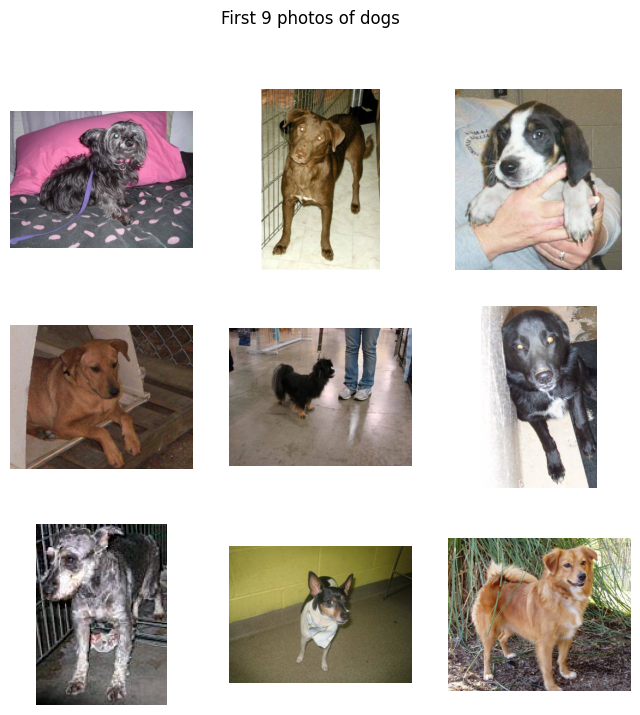

In [ ]:
dog_folder = os.path.join('/content/drive/MyDrive/4geeks/dogs-vs-cats/dogs-vs-cats/train/train/dogs')

dog_files = sorted(os.listdir(dog_folder))[:9]

plt.figure(figsize=(8,8))
for i, f in enumerate(dog_files, 1):
    img = mpimg.imread(os.path.join(dog_folder, f))
    plt.subplot(3,3,i)
    plt.imshow(img)
    plt.axis('off')

plt.suptitle('First 9 photos of dogs')
plt.show()

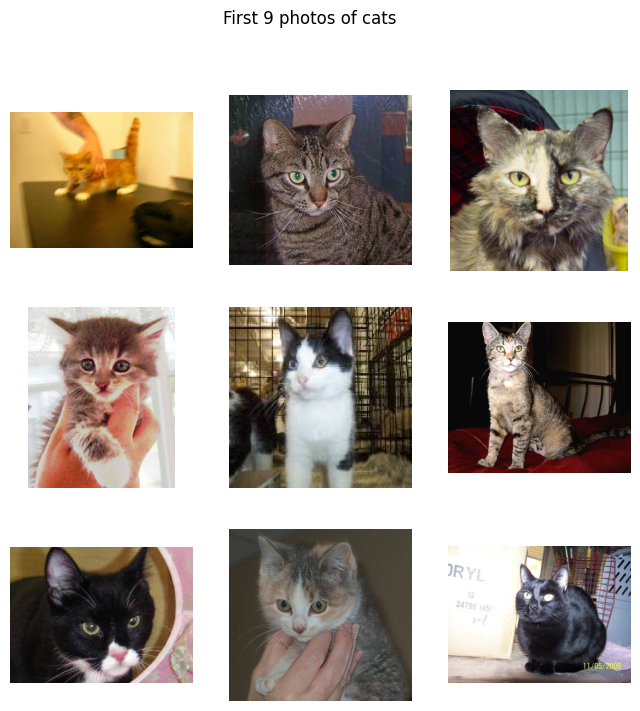

In [ ]:
cat_folder = os.path.join('/content/drive/MyDrive/4geeks/dogs-vs-cats/dogs-vs-cats/train/train/cats')

cat_files = sorted(os.listdir(cat_folder))[:9]

plt.figure(figsize=(8,8))
for i, f in enumerate(cat_files, 1):
    img = mpimg.imread(os.path.join(cat_folder, f))
    plt.subplot(3,3,i)
    plt.imshow(img)
    plt.axis('off')

plt.suptitle('First 9 photos of cats')
plt.show()

Se establece un tamaño de imagen de 200x200 píxeles y un tamaño de lote (batch size) de 32.

tr_gen (Aumento de datos): Configura el generador de entrenamiento para aplicar transformaciones aleatorias (rotación, zoom, desplazamientos y volteo horizontal). Esto ayuda a que el modelo sea más robusto y evita el sobreajuste.

In [ ]:
IMG_SIZE = (200, 200)
BATCH_SIZE = 32

tr_gen = ImageDataGenerator(rescale=1./255,
                            rotation_range=15,
                            zoom_range=0.1,
                            width_shift_range=0.1,
                            height_shift_range=0.1,
                            horizontal_flip=True)

ts_gen = ImageDataGenerator(rescale=1./255)

trdata: Carga las imágenes de entrenamiento aplicando el aumento de datos y mezclándolas aleatoriamente (shuffle=True).

tsdata: Carga las imágenes de prueba/validación. A diferencia del entrenamiento, estas no se mezclan (shuffle=False) para mantener el orden en la evaluación.

In [ ]:
trdata = tr_gen.flow_from_directory('/content/drive/MyDrive/4geeks/dogs-vs-cats/dogs-vs-cats/train/train',
                                    target_size=IMG_SIZE,
                                    batch_size=BATCH_SIZE,
                                    class_mode="categorical",
                                    shuffle=True)

tsdata = ts_gen.flow_from_directory('/content/drive/MyDrive/4geeks/dogs-vs-cats/dogs-vs-cats/train/test',
                                    target_size=IMG_SIZE,
                                    batch_size=BATCH_SIZE,
                                    class_mode="categorical",
                                    shuffle=False)

Found 24891 images belonging to 2 classes.
Found 13498 images belonging to 2 classes.


Se extrae un único lote (batch) de datos usando next(trdata).

Batch X: Confirma que el paquete contiene 32 imágenes de 200x200 píxeles con 3 canales de color (RGB).

Batch y: Confirma que las etiquetas tienen un formato de 2 columnas (debido al class_mode="categorical" definido anteriormente).

In [ ]:
x_batch, y_batch = next(trdata)
print("Batch X:", x_batch.shape)  # (batch, 224,224,3) o (batch,200,200,3)
print("Batch y:", y_batch.shape)  # (batch, 2)

Batch X: (32, 200, 200, 3)
Batch y: (32, 2)
